In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
or_data = pd.DataFrame()
and_data = pd.DataFrame()
xor_data = pd.DataFrame()

In [3]:
or_data['input1'] = [1,1,0,0]
or_data['input2'] = [1,0,1,0]
or_data['output'] = [1,1,1,0]

In [4]:
and_data['input1'] = [1,1,0,0]
and_data['input2'] = [1,0,1,0]
and_data['output'] = [1,0,0,0]

In [5]:
xor_data['input1'] = [1,1,0,0]
xor_data['input2'] = [1,0,1,0]
xor_data['output'] = [0,1,1,0]

In [6]:
or_data

,input1,input2,output
0,1,1,1
1,1,0,1
2,0,1,1
3,0,0,0


<Axes: xlabel='input1', ylabel='input2'>

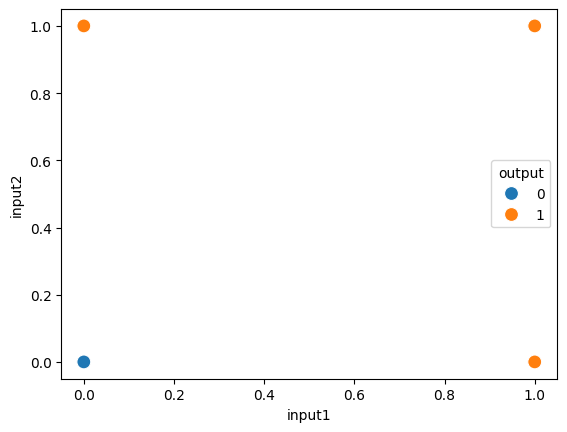

In [8]:
sns.scatterplot(x=or_data['input1'],y=or_data['input2'],hue=or_data['output'],s=100)

<Axes: xlabel='input1', ylabel='input2'>

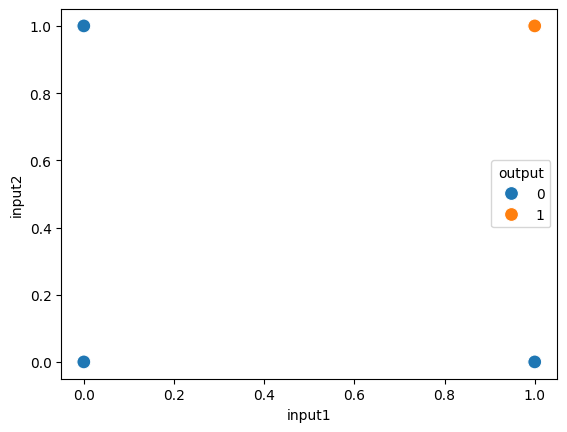

In [10]:
sns.scatterplot(x=and_data['input1'],y=and_data['input2'],hue=and_data['output'],s=100)

<Axes: xlabel='input1', ylabel='input2'>

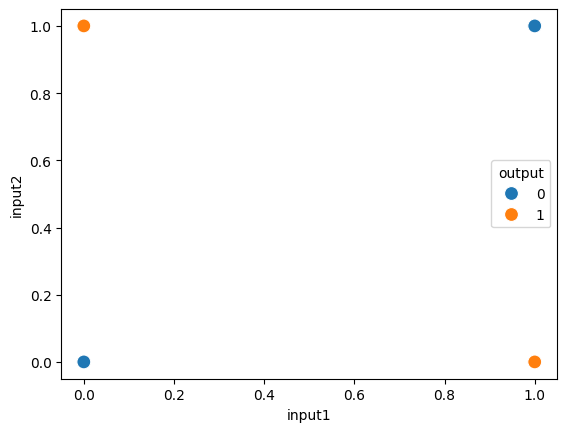

In [11]:
sns.scatterplot(x=xor_data['input1'],y=xor_data['input2'],hue=xor_data['output'],s=100)

In [12]:
from sklearn.linear_model import Perceptron

In [13]:
clf1 = Perceptron()
clf2 = Perceptron()
clf3 = Perceptron()

In [27]:
# clf1.fit(or_data.iloc[:,0:2],or_data.iloc[:,-1]) # Because scikit-learn internally converts pandas data into NumPy arrays before training.

clf1.fit(or_data.iloc[:,0:2].values,or_data.iloc[:,-1].values)
clf2.fit(and_data.iloc[:,0:2].values,and_data.iloc[:,-1].values)
clf3.fit(xor_data.iloc[:,0:2].values,xor_data.iloc[:,-1].values)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,0


In [28]:
clf1.coef_

array([[2., 2.]])

In [29]:
clf1.intercept_

array([-1.])

In [41]:
m1 = -(clf1.coef_[0][0]/clf1.coef_[0][1])
b1 = -(clf1.intercept_/clf1.coef_[0][1])
print(m,b)

-1.0 [0.5]


In [42]:
x1 = np.linspace(-1,1,5)
y1 = -x1 + 0.5


<Axes: xlabel='input1', ylabel='input2'>

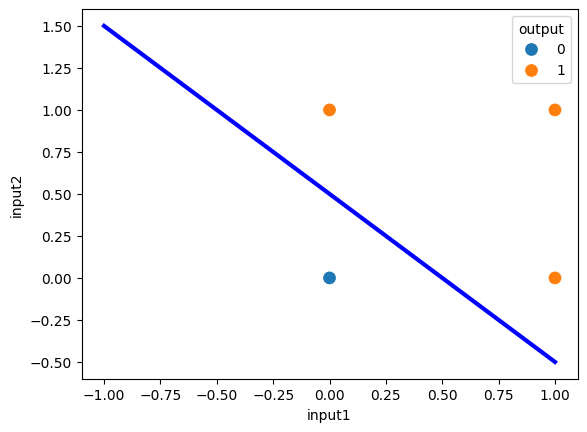

In [43]:
plt.plot(x1,y1,color='blue',linewidth=3)
sns.scatterplot(x=or_data['input1'],y=or_data['input2'],hue=or_data['output'],s=100)

In [44]:
print(clf2.coef_,clf2.intercept_)

[[2. 2.]] [-2.]


In [45]:
m2 = -(clf2.coef_[0][0]/clf2.coef_[0][1])
b2 = -(clf2.intercept_/clf2.coef_[0][1])
print(m2,b2)

-1.0 [1.]


In [50]:
x2 = np.linspace(-1,1,5)
y2 = -x2 + 1

<Axes: xlabel='input1', ylabel='input2'>

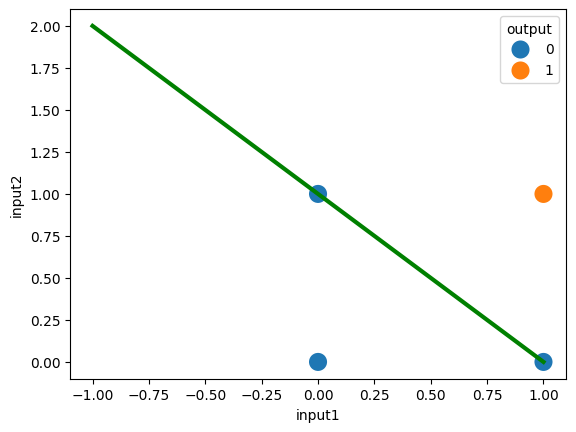

In [52]:
plt.plot(x2,y2,color='green',linewidth=3)
sns.scatterplot(x=and_data['input1'],y=and_data['input2'],hue=and_data['output'],s=200)

In [53]:
print(clf3.coef_,clf3.intercept_)

[[0. 0.]] [0.]


In [57]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

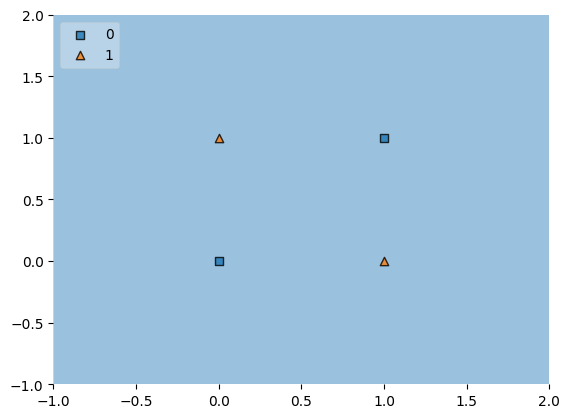

In [58]:
plot_decision_regions(xor_data.iloc[:,0:2].values,xor_data.iloc[:,-1].values,clf=clf3, legend=2)